In [9]:
from tiled.client import from_uri

client = from_uri("http://localhost:8000", api_key="secret")

# List available files
print(list(client))

# Access a specific file and signal
node = client["HAADF"]["HAADF"]

['SI-HAADF', 'HAADF', 'data copy']


In [ ]:
node

In [24]:
node.metadata


{'Acquisition_instrument': {'TEM': {'Stage': {'tilt_alpha': -0.0,
                                              'tilt_beta': -0.004,
                                              'x': -0.000106,
                                              'y': 4.3e-05,
                                              'z': -0.000147},
                                    'beam_energy': 300.0,
                                    'camera_length': 91.0,
                                    'magnification': 910000.0,
                                    'microscope': 'Titan'}},
 'General': {'FileIO': {'0': {'hyperspy_version': '2.4.0',
                              'io_plugin': 'rsciio.emd',
                              'operation': 'load',
                              'timestamp': '2026-04-05T15:59:56.345575-04:00'}},
             'date': '2025-11-15',
             'original_filename': 'HAADF.emd',
             'time': '15:33:40-05:00',
             'time_zone': 'EDT',
             'title': 'HAADF'},
 'Signa

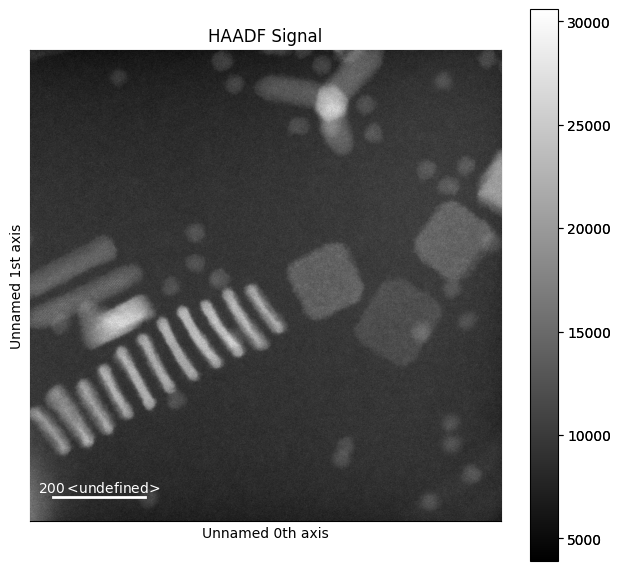

In [14]:
from tiled.client import from_uri
import hyperspy.api as hs
import numpy as np

client = from_uri("http://localhost:8000", api_key="secret")

node = client["HAADF"]["HAADF"]
data = node.read()
meta = node.metadata

# Reconstruct as HyperSpy signal
signal = hs.signals.Signal2D(data)

# Optionally restore metadata
signal.metadata.General.title = meta.get("title", "HAADF")
signal.original_metadata.add_dictionary(meta)

# Plot
signal.plot()

## searching through data

In [28]:
# # full text search on the date string
# from tiled.queries import FullText
# results = client.search(FullText("2025-11-15"))
from tiled.queries import Key

# exact date match
results = client.search(Key("General.date") == "2025-11-15")

# or if the key is at the top level
results = client.search(Key("date") == "2025-11-15")

In [30]:
results

<Container {}>

In [31]:
# browse all nodes, filter by metadata locally
for key, node in client.items():
    meta = node.metadata
    date = meta.get("General", {}).get("date", "")
    if date == "2025-11-15":
        print(key, date)

In [33]:
# Search by metadata key/value:

from tiled.client import from_uri
from tiled.queries import Contains, Eq, Key

client = from_uri("http://localhost:8000", api_key="secret")

# Find all datasets where a metadata key equals a value
results = client.search(Key("beam_energy") == "300")

# iterate results without downloading data
for key, node in results.items():
    print(key, node.metadata)

In [21]:
#Other query types:

from tiled.queries import Contains, Eq, NotEq, Regex, In, FullText

# full text search across all metadata
client.search(FullText("HAADF"))

# # regex on a field
# client.search(Regex("instrument", ".*TEM.*"))

# # check if a value is in a list field
# client.search(In("signal_type", ["HAADF", "BF"]))

<Container {}>

In [18]:
# chain searches
# AND — just chain .search() calls
results = client.search(Key("microscope") == "Nion") \
               .search(FullText("EELS"))

# then only fetch metadata, not data
for key, node in results.items():
    print(key)
    print(node.metadata)
    # data is NOT downloaded until you call .read()

## read the sqlite db

In [23]:
import sqlite3
conn = sqlite3.connect("/tmp/tiled_catalog.db")
cursor = conn.cursor()

# list tables
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
print(cursor.fetchall())

# see all nodes
cursor.execute("SELECT * FROM nodes")
for row in cursor.fetchall():
    print(row)

conn.close()

[('nodes',), ('metadata_fts5',), ('metadata_fts5_data',), ('metadata_fts5_idx',), ('metadata_fts5_docsize',), ('metadata_fts5_config',), ('structures',), ('assets',), ('nodes_closure',), ('data_sources',), ('revisions',), ('data_source_asset_association',), ('alembic_version',)]
(0, None, '', 'container', '{}', '[]', '{}', '2026-04-05 18:27:48', '2026-04-05 18:27:48')
(1, 0, 'SI-HAADF', 'container', '{}', '[]', '{}', '2026-04-05 19:48:54', '2026-04-05 19:48:54')
(2, 0, 'HAADF', 'container', '{}', '[]', '{}', '2026-04-05 19:48:54', '2026-04-05 19:48:54')
(3, 0, 'data copy', 'container', '{}', '[]', '{}', '2026-04-05 19:48:54', '2026-04-05 19:48:54')
(4, 3, 'SI-HAADF', 'container', '{}', '[]', '{}', '2026-04-05 19:48:54', '2026-04-05 19:48:54')
(5, 3, 'HAADF', 'container', '{}', '[]', '{}', '2026-04-05 19:48:54', '2026-04-05 19:48:54')
